In [1]:
import os
from dotenv import load_dotenv
ROOT = "../" # Base directory relative to this notebook's location. Adjust if the notebook is moved
CSV_DIR = os.path.join(ROOT, "csv", "historical-data")
JSON_DIR = os.path.join(ROOT, "json")
DOTENV_PATH = os.path.join(ROOT, '../../apis/.env') # Adjust to .env file location
if load_dotenv(DOTENV_PATH):
    abs_path = os.path.abspath(DOTENV_PATH)
    drive, rel = os.path.splitdrive(abs_path)
    parts = rel.strip(os.sep).split(os.sep)
    masked = parts.copy()
    masked_parts = 1  # adjust to mask parts of your path
    max_maskable = max(0, len(parts) - 2)
    for i in range(min(masked_parts, max_maskable)):
        idx = len(parts) - 3 - i
        masked[idx] = "***"
    prefix = f"{drive}{os.sep}" if drive else (os.sep if abs_path.startswith(os.sep) else "")
    print(f"Loaded .env from {prefix}{os.sep.join(masked)}")
else:
    print("Failed to load .env file.")

API_KEY = os.getenv("AEMET_API_KEY")

def mask_token(token, unmasked_chars=3):
    return token[:unmasked_chars] + '*' * (len(token) - unmasked_chars*2) + token[-unmasked_chars:]
print(f"AEMET_API_KEY: {mask_token(API_KEY)}")

# Variables de ejecución avanzadas (no es necesario cambiarlas si no se ha alterado la estructura de ficheros del proyecto):
DB_FILE = "db/thematic_screener.db" # Sólo necesario si DOWNLOAD_REMOTE_DB = False
import sys
sys.path.append(ROOT)

from src.aemet_helpers import AemetClient
from src.weather_data_download import download_station_data, cast_columns
import pandas as pd
import json
import matplotlib.pyplot as plt
import time

Loaded .env from c:\Users\david\***\apis\.env
AEMET_API_KEY: eyJ***********************************************************************************************************************************************************************************************************************************************************************************************************rF4


In [2]:
locations_dict = os.path.join(JSON_DIR, "locations.json")
with open(locations_dict, "r", encoding="utf-8") as f:
    locations_df = pd.DataFrame(
        list(json.load(f).items()),
        columns=["code", "location"]
    )

display(locations_df.sample(5))

,code,location
162,2017Y,BARRIOMARTIN-EL ROBLEDO
535,8059C,ALCOY
74,1167H,CABAÑA VERÓNICA PARQUE NACIONAL PICOS DE EUROPA
396,5412X,PRIEGO DE CÓRDOBA SAN FELIX
782,C612F,TEJEDA-CRUZ DE TEJEDA


### Individual download

In [ ]:
client = AemetClient(API_KEY)
station_id = "5996B"
station_name = locations_df[locations_df["code"] == station_id]["location"].values[0]
df = download_station_data(client, station_id=station_id, start_date="2021-01-01", max_retries=5, sleep_seconds=8)

Fetching data for station 5996B from 2021-01-01 to 2021-06-29...
✓ Retrieved 180 records (from 2021-01-01 to 2021-06-29)
Fetching data for station 5996B from 2021-06-30 to 2021-12-26...
✓ Retrieved 180 records (from 2021-06-30 to 2021-12-26)
Fetching data for station 5996B from 2021-12-27 to 2022-06-24...
✓ Retrieved 180 records (from 2021-12-27 to 2022-06-24)
Fetching data for station 5996B from 2022-06-25 to 2022-12-21...
✓ Retrieved 179 records (from 2022-06-25 to 2022-12-21)
Fetching data for station 5996B from 2022-12-22 to 2023-06-19...
✓ Retrieved 180 records (from 2022-12-22 to 2023-06-19)
Fetching data for station 5996B from 2023-06-20 to 2023-12-16...
✓ Retrieved 180 records (from 2023-06-20 to 2023-12-16)
Fetching data for station 5996B from 2023-12-17 to 2024-06-13...
✓ Retrieved 170 records (from 2023-12-17 to 2024-06-13)
Fetching data for station 5996B from 2024-06-14 to 2024-12-10...
✗ Error: 429 Client Error: Too Many Requests for url: https://opendata.aemet.es/opendata

In [4]:
display(df.head(3))
print("...")
display(df.tail(3))

,fecha,indicativo,nombre,provincia,altitud,tmed,prec,tmin,horatmin,tmax,horatmax,dir,velmedia,racha,horaracha,hrMedia,hrMax,horaHrMax,hrMin,horaHrMin
0,2021-01-01,5996B,BARBATE,CADIZ,4,"10,4","2,4","7,2",23:16,"13,6",15:49,31,"3,9","12,5",01:40,80,98,02:30,59,13:40
1,2021-01-02,5996B,BARBATE,CADIZ,4,"8,2","0,0","3,6",07:39,"12,8",14:47,29,"2,2","6,4",12:20,78,100,08:30,59,13:50
2,2021-01-03,5996B,BARBATE,CADIZ,4,"7,2","0,0","1,0",07:24,"13,5",12:47,26,"1,7","7,2",14:30,77,100,Varias,53,14:00


...


,fecha,indicativo,nombre,provincia,altitud,tmed,prec,tmin,horatmin,tmax,horatmax,dir,velmedia,racha,horaracha,hrMedia,hrMax,horaHrMax,hrMin,horaHrMin
1951,2026-05-17,5996B,BARBATE,CADIZ,4,"18,4","0,0","14,5",06:37,"22,4",08:50,26,"4,2","9,2",13:20,78,96,04:40,55,16:00
1952,2026-05-18,5996B,BARBATE,CADIZ,4,"17,8","0,0","13,8",05:43,"21,7",17:37,99,"4,2","7,8",Varias,70,94,06:20,56,17:40
1953,2026-05-19,5996B,BARBATE,CADIZ,4,"18,7","0,0","11,2",04:14,"26,2",17:15,99,"3,3","8,6",13:50,72,95,Varias,42,17:20


In [5]:
schema_path = os.path.join(JSON_DIR, "data-fields.json")
df = cast_columns(df, schema_path)
print("\nColumn types:")
for col in df.columns:
    print(f"{col}: {df[col].dtype}")


Column types:
fecha: datetime64[ns]
indicativo: string
nombre: string
provincia: string
altitud: Int64
tmed: Float64
prec: Float64
tmin: Float64
horatmin: string
tmax: Float64
horatmax: string
dir: Int64
velmedia: Float64
racha: Float64
horaracha: string
hrMedia: Int64
hrMax: Int64
horaHrMax: string
hrMin: Int64
horaHrMin: string


In [6]:
df.to_csv(os.path.join(CSV_DIR,"test-downloads", f"{station_id}_hist.csv"), index=False)

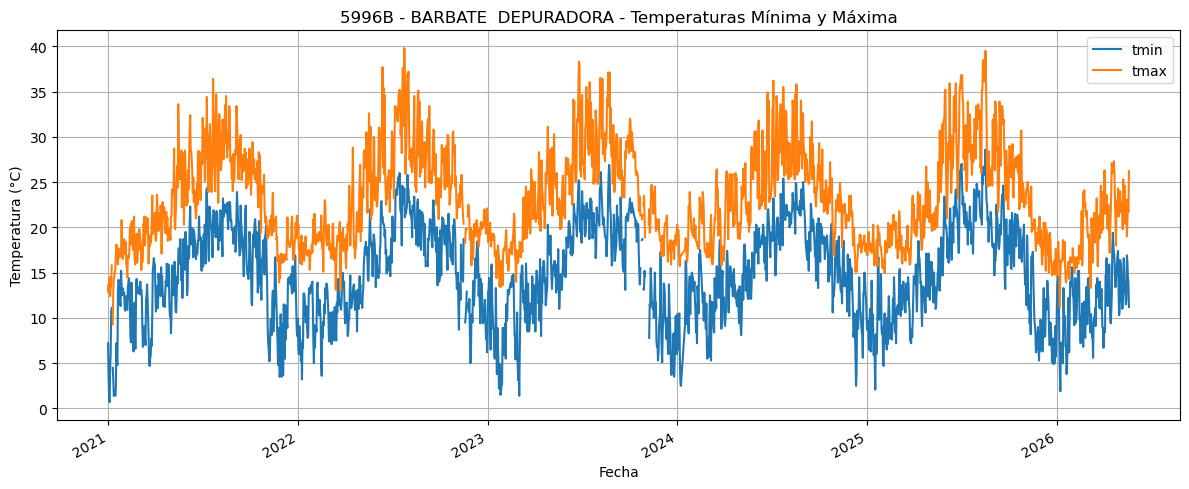

In [9]:
ax = df.sort_values("fecha").plot(x="fecha", y=["tmin", "tmax"], kind="line", figsize=(12,5))
ax.set_xlabel("Fecha")
ax.set_ylabel("Temperatura (°C)")
ax.set_title(f"{station_id} - {station_name} - Temperaturas Mínima y Máxima")
ax.grid(True)
plt.tight_layout()
plt.show()

### All locations

Shuffling the dataframe:

In [17]:
locations_df = locations_df.sample(frac=1).reset_index(drop=True)
display(locations_df)

,code,location
0,9073X,AGURAIN/SALVATIERRA OPAKUA
1,9911X,BALLOBAR DEPÓSITO
2,9257X,ESTERIBAR EMBALSE DE EUGI
3,5972Y,SAN FERNANDO ROA
4,1428,SANTIAGO DE COMPOSTELA/LAVACOLLA
...,...,...
816,1159,SAN VICENTE FARO
817,B334X,LLUCMAJOR II
818,C939T,SABINOSA-BALNEARIO
819,C668V,AGAETE - SUERTE ALTA


In [18]:
client = AemetClient(API_KEY)
schema_path = os.path.join(JSON_DIR, "data-fields.json")
max_downloads = 10

exceptions =  ['B341X', '1178I', '6335O', '6307C', 'C469E', '1191D','1103X', 
               '6299I', '8191Y', '5103F', '5051X', '7019X']

downloads = 0
for station_id in locations_df["code"].astype(str).unique():
    # print(f"iter. {downloads+1}/{len(locations_df)}")
    # Skip exceptions
    if station_id in exceptions:
        print(f"Skipping {station_id}: in exceptions list")
        continue
    # stop early if max_downloads is set and already reached
    if max_downloads is not None and downloads >= int(max_downloads):
        print(f"Reached max_downloads ({max_downloads}); stopping.")
        break

    out_path = os.path.join(CSV_DIR, f"{station_id}_hist.csv")
    if os.path.exists(out_path):
        print(f"Skipping {station_id}: file exists")
        continue
    try:
        df_loc = download_station_data(client, station_id=station_id, start_date="2021-01-01", max_retries=7, sleep_seconds=12)
        if df_loc is None or df_loc.empty:
            print(f"No data for {station_id}")
            continue
        df_loc = cast_columns(df_loc, schema_path)
        df_loc.to_csv(out_path, index=False)
        downloads += 1
        print(f"Saved {out_path} ({downloads} downloads)")
    except Exception as e:
        print(f"Error downloading {station_id}: {e}")

    # check again after a successful download
    if max_downloads is not None and downloads >= int(max_downloads):
        print(f"Reached max_downloads ({max_downloads}); stopping.")
        break

    time.sleep(3)

Skipping 9073X: file exists
Skipping 9911X: file exists
Skipping 9257X: file exists
Fetching data for station 5972Y from 2021-01-01 to 2021-06-29...
✗ Error: No datos URL returned by API (Retry 1/7)
Fetching data for station 5972Y from 2021-01-01 to 2021-06-29...
✗ Error: No datos URL returned by API (Retry 2/7)
Fetching data for station 5972Y from 2021-01-01 to 2021-06-29...
✗ Error: No datos URL returned by API (Retry 3/7)
Fetching data for station 5972Y from 2021-01-01 to 2021-06-29...
✗ Error: No datos URL returned by API (Retry 4/7)
Fetching data for station 5972Y from 2021-01-01 to 2021-06-29...
✗ Error: No datos URL returned by API (Retry 5/7)
Fetching data for station 5972Y from 2021-01-01 to 2021-06-29...
✗ Error: No datos URL returned by API (Retry 6/7)
Fetching data for station 5972Y from 2021-01-01 to 2021-06-29...
✗ Error: No datos URL returned by API (Retry 7/7)
Failed to retrieve data after 7 retries. Stopping.
No data for 5972Y
Skipping 1428: file exists
Skipping 0421X: